# Process AIT Log Data Set V2.0

In [87]:
import pandas as pd
import hashlib
import numpy as np
import matplotlib.pyplot as plt

## Concatenate Sensor Files

In [88]:
dataset = "aitv2"
scenario = "fox"
data_dir = f"../data/interim/{dataset}/{scenario}/flows_labeled"
sensor_hosts = ["cloud_share", "inet_firewall", "internal_share", "intranet_server", "mail", "vpn", "webserver"]

In [89]:
all_sensor_files = []
for sensor_host in sensor_hosts:
    df = pd.read_csv(
        f"{data_dir}/{sensor_host}_labeled.csv"
    )
    df["sensor_host"] = sensor_host
    all_sensor_files.append(df)

df_all_sensors = pd.concat(all_sensor_files, ignore_index=True)
df_all_sensors = df_all_sensors.sort_values("start_time").reset_index(drop=True)

df_all_sensors.head()

,flow_id,start_time,end_time,duration,src_ip,sport,dst_ip,dport,proto,service,...,missed_bytes,history,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,tunnel_parents,ip_proto,label,sensor_host
0,f0,1.642159e+09,1.642159e+09,61.748287,172.17.128.63,37828,172.17.131.81,22,tcp,-,...,0,ADdaFf,56,5836,65,6176,-,6,benign,mail
1,f0,1.642159e+09,1.642159e+09,0.004262,192.168.128.4,62003,192.168.255.254,53,udp,dns,...,0,Dd,1,276,1,292,-,17,benign,inet_firewall
2,f21513,1.642159e+09,1.642661e+09,501976.017070,10.35.35.206,37150,10.35.35.204,5044,tcp,-,...,0,DadATT,151060,140062920,89624,4852876,-,6,benign,intranet_server
3,f41508,1.642159e+09,1.642661e+09,501976.012480,10.35.33.111,39596,10.35.35.204,5044,tcp,-,...,0,DadATTt,137961,133145969,80513,4340882,-,6,benign,internal_share
4,f7,1.642159e+09,1.642159e+09,94.711953,10.35.33.111,39594,10.35.35.204,5044,tcp,-,...,0,AaDdr,15,3669,12,654,-,6,benign,internal_share


## Trim to Simulation Period

In [90]:
# Convert start_time and end_time from seconds to datetime
df_all_sensors["start_time_dt"] = pd.to_datetime(df_all_sensors["start_time"], unit="s")
df_all_sensors["end_time_dt"] = pd.to_datetime(df_all_sensors["end_time"], unit="s")

print(f"Full dataset time range: {df_all_sensors['start_time_dt'].min()} to {df_all_sensors['end_time_dt'].max()}")
print("Total flows in combined dataset:", len(df_all_sensors))

Full dataset time range: 2022-01-14 11:20:16.140374899 to 2022-01-20 06:47:24.788824081
Total flows in combined dataset: 545340


In [91]:
# Trim to simulation period
sim_start = pd.Timestamp("2022-01-15 00:00")
sim_end   = pd.Timestamp("2022-01-20 00:00")

df_sim = df_all_sensors[(df_all_sensors["start_time_dt"] >= sim_start) & (df_all_sensors["end_time_dt"] <= sim_end)]

print(f"Simulation period: {sim_start} to {sim_end}")
print(f"Total flows in simulation period: {len(df_sim)}")

Simulation period: 2022-01-15 00:00:00 to 2022-01-20 00:00:00
Total flows in simulation period: 488499


## Sanity Check Labeling

### Load Netflow Data

In [92]:
fox_netflows_path = "../data/raw/aitv2/fox_netflows/tcp_complete.csv"
df_netflows = pd.read_csv(fox_netflows_path)
df_netflows_labels_counts = df_netflows["label"].value_counts()
# print(df_netflows_labels_counts)

In [93]:
netflows_labels = df_netflows["label"].unique()
print(netflows_labels)

['browsing/update' 'service_scan' 'online_cracking' 'benign_share' 'proxy'
 'host_discover_dmz' 'SSH' 'mail' 'HTTPS' 'DNS'
 'update/command on unassigned port' 'monitoring' 'HTTP(S) intra' 'HTTP'
 'host_discover_local' 'wpscan' 'dirb_scan' 'upload_rce_shell'
 'check_user_id' 'check_netstat_t' 'read_resolv' 'check_network_config'
 'check_ps_a' 'check_release' 'read_group' 'read_passwd' 'check_date'
 'list_web_dir' 'check_wp_config' 'dump_wp_users' 'read_profile'
 'dns_brute_force_start' 'HTTP(S) DMZ']


### Check Labeling

In [94]:
def get_observed_labels_and_counts(df):
    observed_labels = set()
    observed_labels_counts = {}
    for label in df["label"].unique():
        observed_labels.add(label)
        observed_labels_counts[label] = len(df[df["label"] == label])
    return observed_labels, observed_labels_counts

observed_labels, observed_labels_counts = get_observed_labels_and_counts(df_sim)

In [95]:
print("Unique labels observed across all sensors:")
print(list(observed_labels))

print("Labels in netflows but not observed:")
print([label for label in netflows_labels if label not in observed_labels])

Unique labels observed across all sensors:
['HTTPS', 'upload_rce_shell', 'service_scan', 'update/command on unassigned port', 'SSH', 'dns_brute_force_start', 'browsing/update', 'online_cracking', 'read_profile', 'host_discover_dmz', 'read_group', 'read_passwd', 'dump_wp_users', 'DNS', 'monitoring', 'HTTP', 'proxy', 'mail', 'check_netstat_t', 'check_release', 'host_discover_local', 'dirb_scan', 'benign', 'list_web_dir', 'HTTP(S) intra', 'HTTP(S) DMZ', 'wpscan', 'check_ps_a', 'check_date', 'check_wp_config', 'read_resolv', 'check_user_id', 'check_network_config', 'benign_share']
Labels in netflows but not observed:
[]


In [96]:
for label in observed_labels:
    if label == "benign":
        continue
    
    print(f"Observed number of flows with label '{label}': {observed_labels_counts[label]}")
    print(f"Number of flows with label '{label}' in netflows: {df_netflows_labels_counts.get(label, 0)}")
    print()

Observed number of flows with label 'HTTPS': 69556
Number of flows with label 'HTTPS' in netflows: 34918

Observed number of flows with label 'upload_rce_shell': 4
Number of flows with label 'upload_rce_shell' in netflows: 2

Observed number of flows with label 'service_scan': 343
Number of flows with label 'service_scan' in netflows: 262

Observed number of flows with label 'update/command on unassigned port': 2
Number of flows with label 'update/command on unassigned port' in netflows: 2

Observed number of flows with label 'SSH': 35
Number of flows with label 'SSH' in netflows: 19

Observed number of flows with label 'dns_brute_force_start': 1
Number of flows with label 'dns_brute_force_start' in netflows: 1

Observed number of flows with label 'browsing/update': 25154
Number of flows with label 'browsing/update' in netflows: 27876

Observed number of flows with label 'online_cracking': 114
Number of flows with label 'online_cracking' in netflows: 60

Observed number of flows with l

### Remove Duplicates

In [97]:
def compute_hash(df: pd.DataFrame, columns: list) -> pd.Series:
    return (
        df[columns]
        .astype(str)
        .agg("|".join, axis=1)
        .apply(lambda x: hashlib.md5(x.encode()).hexdigest())
    )

In [98]:
df_sim["start_time_match"] = df_sim["start_time"].round(1)
df_sim["end_time_match"] = df_sim["end_time"].round(1)

match_columns = [col for col in df_sim.columns if col not in ["flow_id", "start_time", "end_time", "sensor_host"]]
match_columns.append("start_time_match")
match_columns.append("end_time_match")
print("Matching columns:", match_columns)

# Compute flow hash for all sensor flows
df_sim["flow_hash"] = compute_hash(df_sim, match_columns)

Matching columns: ['duration', 'src_ip', 'sport', 'dst_ip', 'dport', 'proto', 'service', 'orig_bytes', 'resp_bytes', 'conn_state', 'local_orig', 'local_resp', 'missed_bytes', 'history', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'tunnel_parents', 'ip_proto', 'label', 'start_time_dt', 'end_time_dt', 'start_time_match', 'end_time_match', 'start_time_match', 'end_time_match']


/tmp/ipykernel_29555/3310084976.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sim["start_time_match"] = df_sim["start_time"].round(1)
/tmp/ipykernel_29555/3310084976.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sim["end_time_match"] = df_sim["end_time"].round(1)
/tmp/ipykernel_29555/3310084976.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http

In [99]:
# Remove duplicates by keeping only one entry per flow hash and sensor host
df_sim_no_duplicates = (
    df_sim
    .drop_duplicates(subset=["flow_hash", "sensor_host"])
    .drop(columns=["flow_hash", "start_time_match", "end_time_match"])
)

print("Original dataset shape:", df_sim.shape)
print("Final dataset shape:", df_sim_no_duplicates.shape)

Original dataset shape: (488499, 30)
Final dataset shape: (358476, 27)


In [100]:
observed_labels_no_duplicates, observed_labels_counts_no_duplicates = \
    get_observed_labels_and_counts(df_sim_no_duplicates)

for label in observed_labels_no_duplicates:
    if label == "benign":
        continue
    
    print(f"Observed number of flows with label '{label}': {observed_labels_counts_no_duplicates[label]}")
    print(f"Number of flows with label '{label}' in netflows: {df_netflows_labels_counts.get(label, 0)}")
    print()

Observed number of flows with label 'HTTPS': 34894
Number of flows with label 'HTTPS' in netflows: 34918

Observed number of flows with label 'upload_rce_shell': 2
Number of flows with label 'upload_rce_shell' in netflows: 2

Observed number of flows with label 'service_scan': 188
Number of flows with label 'service_scan' in netflows: 262

Observed number of flows with label 'update/command on unassigned port': 2
Number of flows with label 'update/command on unassigned port' in netflows: 2

Observed number of flows with label 'SSH': 19
Number of flows with label 'SSH' in netflows: 19

Observed number of flows with label 'dns_brute_force_start': 1
Number of flows with label 'dns_brute_force_start' in netflows: 1

Observed number of flows with label 'browsing/update': 25154
Number of flows with label 'browsing/update' in netflows: 27876

Observed number of flows with label 'online_cracking': 59
Number of flows with label 'online_cracking' in netflows: 60

Observed number of flows with la

### Save Final Dataset

In [101]:
df_sim_no_duplicates.to_csv(f"{data_dir}/all_sensors_labeled.csv", index=False)
print("Combined dataset shape:", df_sim_no_duplicates.shape)
df_sim_no_duplicates.head()

Combined dataset shape: (358476, 27)


,flow_id,start_time,end_time,duration,src_ip,sport,dst_ip,dport,proto,service,...,orig_pkts,orig_ip_bytes,resp_pkts,resp_ip_bytes,tunnel_parents,ip_proto,label,sensor_host,start_time_dt,end_time_dt
51341,f1921,1.642205e+09,1.642205e+09,0.099298,10.35.35.206,60538,91.189.91.157,123,udp,ntp,...,1,76,1,76,-,17,benign,intranet_server,2022-01-15 00:00:00.869369984,2022-01-15 00:00:00.968667984
51342,f14196,1.642205e+09,1.642205e+09,0.098276,192.168.128.4,60538,91.189.91.157,123,udp,ntp,...,1,76,1,76,-,17,benign,inet_firewall,2022-01-15 00:00:00.870096922,2022-01-15 00:00:00.968372822
51343,f3334,1.642205e+09,1.642205e+09,0.053324,172.17.129.140,43702,10.35.33.111,445,tcp,gssapi,...,6,514,4,379,-,6,benign_share,cloud_share,2022-01-15 00:00:02.130912066,2022-01-15 00:00:02.184236050
51345,f5126,1.642205e+09,1.642205e+09,0.051889,172.17.129.140,43702,10.35.33.111,445,tcp,gssapi,...,6,514,4,379,-,6,benign_share,internal_share,2022-01-15 00:00:02.131725073,2022-01-15 00:00:02.183614016
51347,f3335,1.642205e+09,1.642205e+09,0.012432,172.17.129.140,43704,10.35.33.111,445,tcp,gssapi,...,6,514,4,379,-,6,benign_share,cloud_share,2022-01-15 00:00:02.226455927,2022-01-15 00:00:02.238888025


## Plotting

In [102]:
df = df_sim_no_duplicates.copy()

### Plotting Functions

In [103]:
import matplotlib.dates as mdates


In [104]:
def plot_event_raster(df_attack, order, attack=False, invert_y=True):

    plt.figure(figsize=(14, 0.35 * len(order)))

    sample = df_attack.sample(
        min(len(df_attack), 5000),
        random_state=0
    ).sort_values("start_time_dt")

    label_to_idx = {lbl: i for i, lbl in enumerate(order)}

    ys = sample['label'].map(label_to_idx).astype(float)

    # jitter to reveal density
    ys += np.random.uniform(-0.15, 0.15, size=len(ys))

    # horizontal guides
    for y in label_to_idx.values():
        plt.axhline(y, color="lightgray", lw=0.5, zorder=0)

    plt.scatter(
        sample['start_time_dt'],  
        ys,
        s=2,
        alpha=0.5,
        rasterized=True
    )

    plt.yticks(list(label_to_idx.values()), list(label_to_idx.keys()))

    plt.grid(axis="x", linestyle=":", alpha=0.4)

    plt.xlabel("Time")
    plt.ylabel("Event Type")
    plt.title("Attack Event Timeline (Sampled Raster)", pad=12)

    ax = plt.gca()

    if attack:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        plt.xticks(rotation=30)

    if invert_y:
        ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

### Analyze All Events

In [105]:
all_labels = list(netflows_labels)
all_labels.append("benign")
print("All labels (netflows + benign):", all_labels)

All labels (netflows + benign): ['browsing/update', 'service_scan', 'online_cracking', 'benign_share', 'proxy', 'host_discover_dmz', 'SSH', 'mail', 'HTTPS', 'DNS', 'update/command on unassigned port', 'monitoring', 'HTTP(S) intra', 'HTTP', 'host_discover_local', 'wpscan', 'dirb_scan', 'upload_rce_shell', 'check_user_id', 'check_netstat_t', 'read_resolv', 'check_network_config', 'check_ps_a', 'check_release', 'read_group', 'read_passwd', 'check_date', 'list_web_dir', 'check_wp_config', 'dump_wp_users', 'read_profile', 'dns_brute_force_start', 'HTTP(S) DMZ', 'benign']


In [106]:
phase_bounds_sim = (
    df[df['label'].isin(all_labels)]
    .groupby('label')['start_time_dt']
    .agg(['min', 'max'])
    .sort_values('min')
)

phase_bounds_sim

,min,max
label,,
benign,2022-01-15 00:00:00.869369984,2022-01-19 23:59:59.055074930
benign_share,2022-01-15 00:00:02.130912066,2022-01-19 23:45:03.798696995
monitoring,2022-01-15 00:09:12.140852928,2022-01-19 23:39:09.491734982
browsing/update,2022-01-15 00:51:09.932920933,2022-01-19 23:06:25.648124933
HTTP(S) intra,2022-01-15 06:20:14.662290096,2022-01-19 20:32:45.343213081
HTTP,2022-01-15 06:26:52.650701046,2022-01-19 22:04:08.124687910
HTTPS,2022-01-15 06:26:52.674741983,2022-01-19 22:11:44.237390041
proxy,2022-01-15 06:26:52.702621937,2022-01-19 22:11:44.253081082
mail,2022-01-15 06:30:27.343759060,2022-01-19 22:06:32.650038004


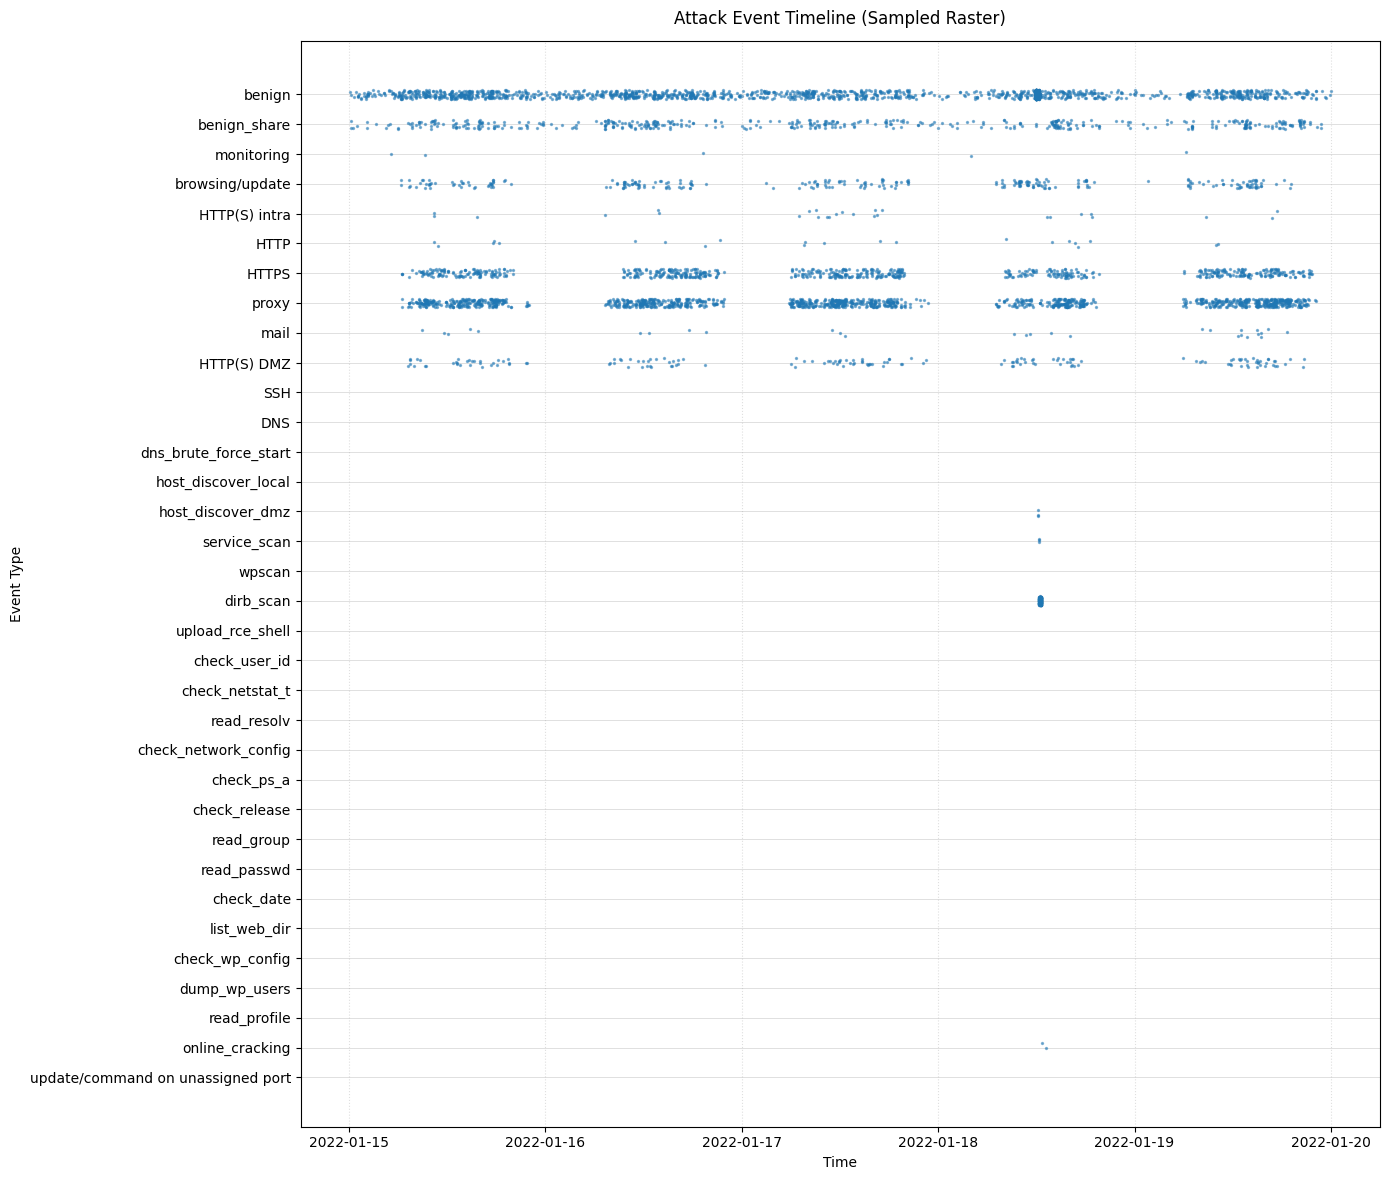

In [107]:
order_sim = phase_bounds_sim.index.tolist()
plot_event_raster(df_sim, order_sim)

### Only Attacks

In [108]:
benign_labels = ["DNS", "SSH", "HTTP(S) DMZ", "mail", "proxy", "HTTPS", "HTTP", "HTTP(S) intra", "browsing/update", "monitoring", "benign_share", "benign"]
attack_labels = [lbl for lbl in all_labels if lbl not in benign_labels]
print("Benign labels:", benign_labels)
print("Attack labels:", attack_labels)

Benign labels: ['DNS', 'SSH', 'HTTP(S) DMZ', 'mail', 'proxy', 'HTTPS', 'HTTP', 'HTTP(S) intra', 'browsing/update', 'monitoring', 'benign_share', 'benign']
Attack labels: ['service_scan', 'online_cracking', 'host_discover_dmz', 'update/command on unassigned port', 'host_discover_local', 'wpscan', 'dirb_scan', 'upload_rce_shell', 'check_user_id', 'check_netstat_t', 'read_resolv', 'check_network_config', 'check_ps_a', 'check_release', 'read_group', 'read_passwd', 'check_date', 'list_web_dir', 'check_wp_config', 'dump_wp_users', 'read_profile', 'dns_brute_force_start']


In [109]:
attack_start_true = pd.Timestamp("2022-01-18 11:59")
attack_end_true   = pd.Timestamp("2022-01-18 13:15")

print(f"True attack period:")
print(f"{attack_start_true} to {attack_end_true}")
print()

df_attack = df[df["label"].isin(attack_labels)]
attack_start = df_attack["start_time_dt"].min()
attack_end = df_attack["end_time_dt"].max()

print(f"Attack period based on attack labels:")
print(f"{attack_start} to {attack_end}")
print()

print(f"Total attack flows in attack period: {len(df_attack)}")

True attack period:
2022-01-18 11:59:00 to 2022-01-18 13:15:00

Attack period based on attack labels:
2022-01-18 11:59:14.515575886 to 2022-01-18 13:14:51.076342106

Total attack flows in attack period: 8826


In [110]:
phase_bounds_attack = (
    df_attack[df_attack['label'].isin(attack_labels)]
    .groupby('label')['start_time_dt']
    .agg(['min', 'max'])
    .sort_values('min')
)

phase_bounds_attack

,min,max
label,,
dns_brute_force_start,2022-01-18 11:59:14.515575886,2022-01-18 11:59:14.515575886
host_discover_local,2022-01-18 11:59:25.918654919,2022-01-18 12:02:40.928086042
host_discover_dmz,2022-01-18 12:02:53.880317926,2022-01-18 12:14:50.528302908
service_scan,2022-01-18 12:17:14.234992027,2022-01-18 12:17:43.861294031
wpscan,2022-01-18 12:17:50.429045916,2022-01-18 12:18:13.388248920
dirb_scan,2022-01-18 12:18:30.335740089,2022-01-18 12:37:48.927057981
upload_rce_shell,2022-01-18 12:38:00.677339077,2022-01-18 12:38:00.677897930
check_user_id,2022-01-18 12:38:04.704194069,2022-01-18 12:38:04.704286098
check_netstat_t,2022-01-18 12:38:06.522208929,2022-01-18 12:38:06.522558928


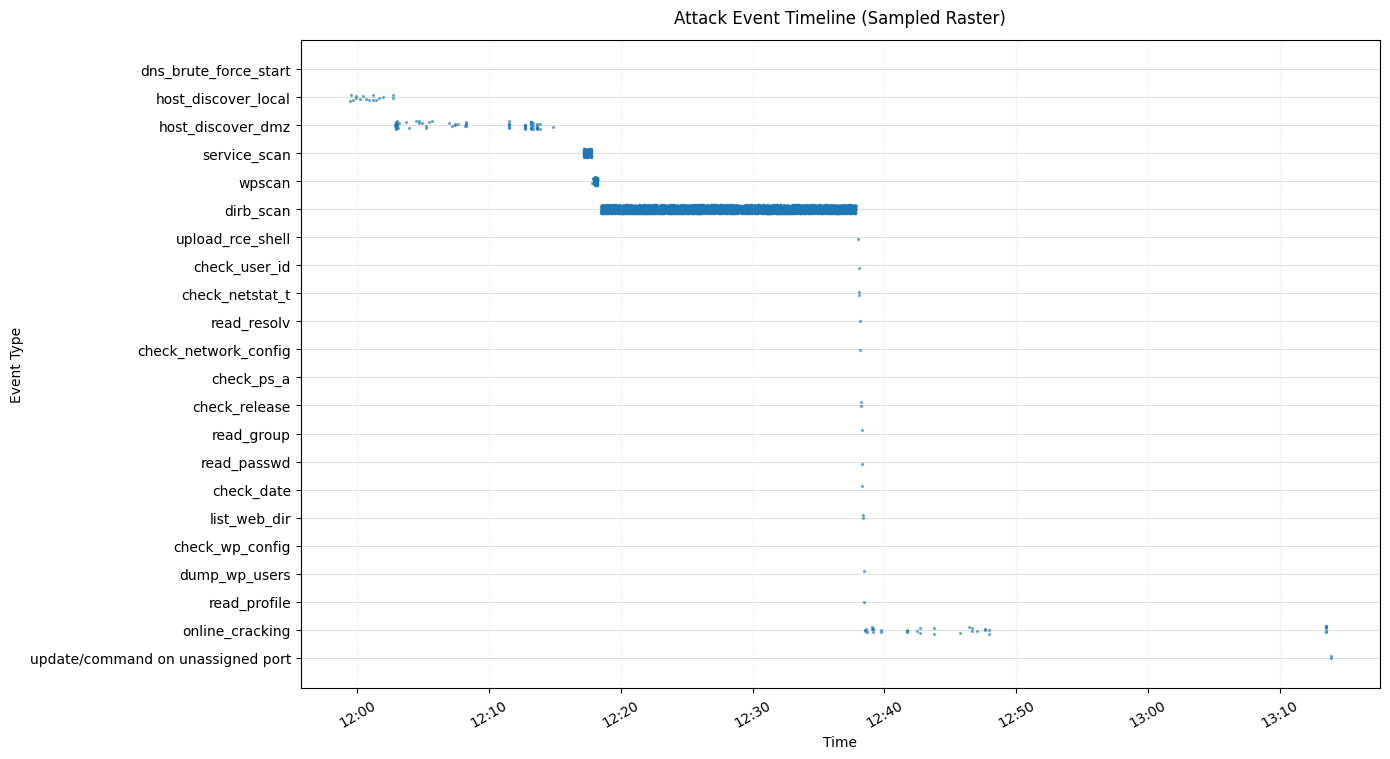

In [111]:
order_attack = phase_bounds_attack.index.tolist()
plot_event_raster(df_attack=df_attack, order=order_attack, attack=True)

## Dataset Statistics

In [112]:
def label_stats(df, sensor_host, plot_bar=True):
    label_counts = df["label"].value_counts()
    print("Label Distribution for {}:".format(sensor_host))
    print(label_counts)

    if plot_bar:
        bar = label_counts.plot(kind="bar")
        bar.set_title("Label Distribution - {}".format(sensor_host))
        bar.set_yscale("log")
    print()

In [113]:
def dataset_stats(df, print_details=True):
    total_flows = len(df)
    unique_src_ips = df["src_ip"].nunique()
    unique_dst_ips = df["dst_ip"].nunique()
    unique_src_ports = df["sport"].nunique()
    unique_dst_ports = df["dport"].nunique()

    if print_details:
        print(f"Total Flows: {total_flows}")
        print(f"Unique Source IPs: {unique_src_ips}")
        print(f"Unique Destination IPs: {unique_dst_ips}")
        print(f"Unique Source Ports: {unique_src_ports}")
        print(f"Unique Destination Ports: {unique_dst_ports}")

    return {
        "total_flows": total_flows,
        "unique_src_ips": unique_src_ips,
        "unique_dst_ips": unique_dst_ips,
        "unique_src_ports": unique_src_ports,
        "unique_dst_ports": unique_dst_ports,
    }

In [114]:
def dataset_stats_detailed(df, print_details=True):
    src_ips = df["src_ip"].value_counts()
    dst_ips = df["dst_ip"].value_counts()
    src_ports = df["sport"].value_counts()
    dst_ports = df["dport"].value_counts()

    if print_details:
        print("Total Flows:", len(df))

        print("\n --- IP distribution ---")
        print(f"\nSource IPs ({len(src_ips)}):")
        print(src_ips)
        print(f"\nDestination IPs ({len(dst_ips)}):")
        print(dst_ips)

        print("\n --- Port distribution ---")
        print(f"Source Ports ({len(src_ports)}):")
        print(src_ports)
        print(f"\nDestination Ports ({len(dst_ports)}):")
        print(dst_ports)

    return src_ips, dst_ips, src_ports, dst_ports

Label Distribution for webserver:
label
dirb_scan                            8254
service_scan                          188
host_discover_dmz                     136
wpscan                                128
online_cracking                        59
host_discover_local                    30
read_group                              2
upload_rce_shell                        2
check_netstat_t                         2
check_user_id                           2
check_network_config                    2
check_ps_a                              2
check_release                           2
read_resolv                             2
check_wp_config                         2
read_passwd                             2
list_web_dir                            2
check_date                              2
read_profile                            2
dump_wp_users                           2
update/command on unassigned port       2
dns_brute_force_start                   1
Name: count, dtype: int64



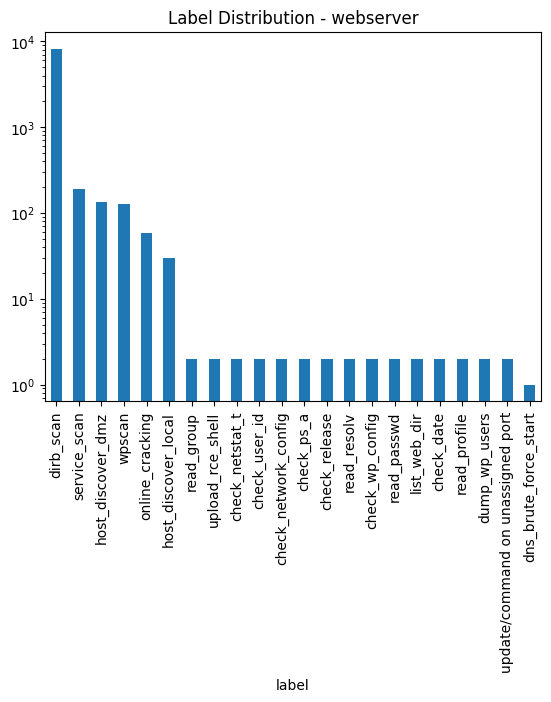

In [115]:
label_stats(df_attack, sensor_host)

In [116]:
# Sim dataset stats
dataset_stats(df)

Total Flows: 358476
Unique Source IPs: 115
Unique Destination IPs: 11336
Unique Source Ports: 43976
Unique Destination Ports: 2410


{'total_flows': 358476,
 'unique_src_ips': 115,
 'unique_dst_ips': 11336,
 'unique_src_ports': 43976,
 'unique_dst_ports': 2410}

In [117]:
# Attack flows stats
dataset_stats(df_attack)

Total Flows: 8826
Unique Source IPs: 4
Unique Destination IPs: 9
Unique Source Ports: 4329
Unique Destination Ports: 11


{'total_flows': 8826,
 'unique_src_ips': 4,
 'unique_dst_ips': 9,
 'unique_src_ports': 4329,
 'unique_dst_ports': 11}

In [118]:
dataset_stats_detailed(df_attack)

Total Flows: 8826

 --- IP distribution ---

Source IPs (4):
src_ip
172.17.130.196    8753
192.168.130.77      68
192.168.128.4        3
10.35.35.206         2
Name: count, dtype: int64

Destination IPs (9):
dst_ip
10.35.35.206       8358
172.17.130.37       345
172.17.129.140       46
192.168.128.4        35
172.17.131.81        22
10.35.33.111         14
192.168.130.77        4
172.17.128.1          1
192.168.255.254       1
Name: count, dtype: int64

 --- Port distribution ---
Source Ports (4329):
sport
35130    4
35136    4
34854    4
34510    4
34866    4
        ..
57728    2
57808    2
45119    1
48074    1
36962    1
Name: count, Length: 4329, dtype: int64

Destination Ports (11):
dport
443      8650
80        120
587        18
22         10
993         6
139         6
143         4
445         4
25          4
53          2
51898       2
Name: count, dtype: int64


(src_ip
 172.17.130.196    8753
 192.168.130.77      68
 192.168.128.4        3
 10.35.35.206         2
 Name: count, dtype: int64,
 dst_ip
 10.35.35.206       8358
 172.17.130.37       345
 172.17.129.140       46
 192.168.128.4        35
 172.17.131.81        22
 10.35.33.111         14
 192.168.130.77        4
 172.17.128.1          1
 192.168.255.254       1
 Name: count, dtype: int64,
 sport
 35130    4
 35136    4
 34854    4
 34510    4
 34866    4
         ..
 57728    2
 57808    2
 45119    1
 48074    1
 36962    1
 Name: count, Length: 4329, dtype: int64,
 dport
 443      8650
 80        120
 587        18
 22         10
 993         6
 139         6
 143         4
 445         4
 25          4
 53          2
 51898       2
 Name: count, dtype: int64)